## **Juntar os dois ficheiros CSV**

In [59]:
import pandas as pd
df_apt = pd.read_csv('apartamentos.csv', delimiter=';', on_bad_lines='skip', engine='python')
df_casas = pd.read_csv('casas.csv', delimiter=';', on_bad_lines='skip', engine='python')
df_apt.columns = df_apt.columns.str.strip() 
df_casas.columns = df_casas.columns.str.strip()
df_merged = pd.concat([df_apt, df_casas], ignore_index=True) 
df_merged.to_csv('dataset_merged.csv', index=False) 
df = df_merged
print(f"Apartamentos: {len(df_apt)} linhas")
print(f"Casas: {len(df_casas)} linhas")
print(f"Total Junto: {len(df_merged)} linhas")

Apartamentos: 16134 linhas
Casas: 20842 linhas
Total Junto: 36976 linhas


## **Informação sobre o DataSet**

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36976 entries, 0 to 36975
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Index     36976 non-null  int64 
 1   Type      36976 non-null  object
 2   Price     36976 non-null  object
 3   Area      36976 non-null  object
 4   Location  36976 non-null  object
 5   Property  36976 non-null  object
dtypes: int64(1), object(5)
memory usage: 1.7+ MB


## **Descobrir Erros e Diagnóstico**

In [39]:
import pandas as pd
df = pd.read_csv('dataset_merged.csv')
print("\nTipologias encontradas (Amostra):") #Verificar tipologias misturadas das 15 primeiras linhas
print(df['Type'].unique()[:15])
print(f"\nExemplo de Preço 'sujo': {df['Price'].iloc[0]}") #Verificar formato do preço (se tem € ou texto)
print(f"Exemplo de Área 'suja': {df['Area'].iloc[0]}") #Verificar formato da Área
print("\nContagem de Valores Nulos por Coluna:") #Verificar valores nulos (Dados em falta)
print(df.isnull().sum())


Tipologias encontradas (Amostra):
['T2' 'T3' 'T1' 'T4' 'T0' 'T5' 'T6' 'T7' 'T8' 'Detached House'
 'Small Farmhouse' '2-Bedroom' '3-Bedroom' 'Studio' '5-Bedroom']

Exemplo de Preço 'sujo': 185 000,00 €
Exemplo de Área 'suja': 104.70

Contagem de Valores Nulos por Coluna:
Index       0
Type        0
Price       0
Area        0
Location    0
Property    0
dtype: int64


## **Gráficos do Dataset sujo**

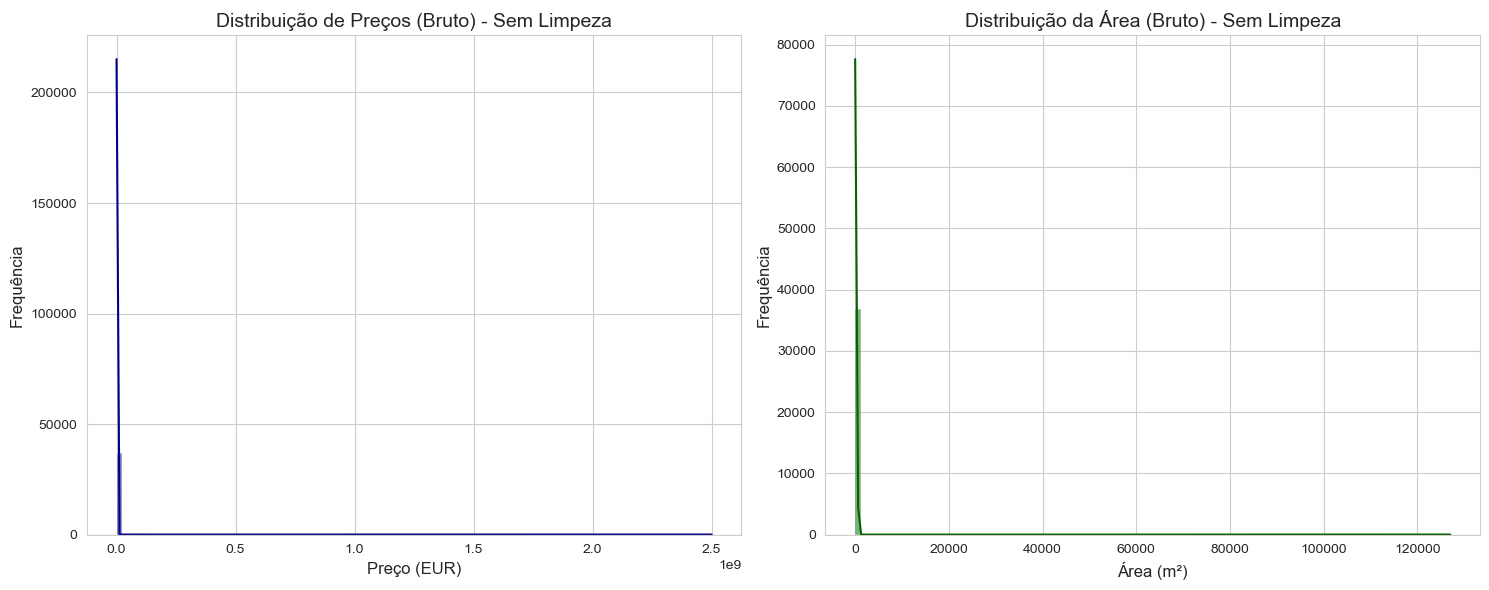

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_bruto = pd.read_csv('dataset_merged.csv')
df_bruto['Price_Num'] = df_bruto['Price'].astype(str).str.replace('€', '').str.replace(' ', '').str.replace('\xa0', '').str.replace(',', '.')
df_bruto['Price_Num'] = pd.to_numeric(df_bruto['Price_Num'], errors='coerce')
df_bruto['Area_Num'] = df_bruto['Area'].astype(str).str.replace('m2', '').str.replace(' ', '').str.replace(',', '.')
df_bruto['Area_Num'] = pd.to_numeric(df_bruto['Area_Num'], errors='coerce')
df_plot = df_bruto.dropna(subset=['Price_Num', 'Area_Num'])

sns.set_style("whitegrid")
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_plot['Price_Num'], kde=True, bins=100, color='darkblue')
plt.title('Distribuição de Preços (Bruto) - Sem Limpeza', fontsize=14)
plt.xlabel('Preço (EUR)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.subplot(1, 2, 2)
sns.histplot(df_plot['Area_Num'], kde=True, bins=100, color='darkgreen')
plt.title('Distribuição da Área (Bruto) - Sem Limpeza', fontsize=14)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Frequência', fontsize=12)

plt.tight_layout()
plt.show()

C:\Users\Sara Simões\AppData\Local\Temp\ipykernel_25908\1866752593.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


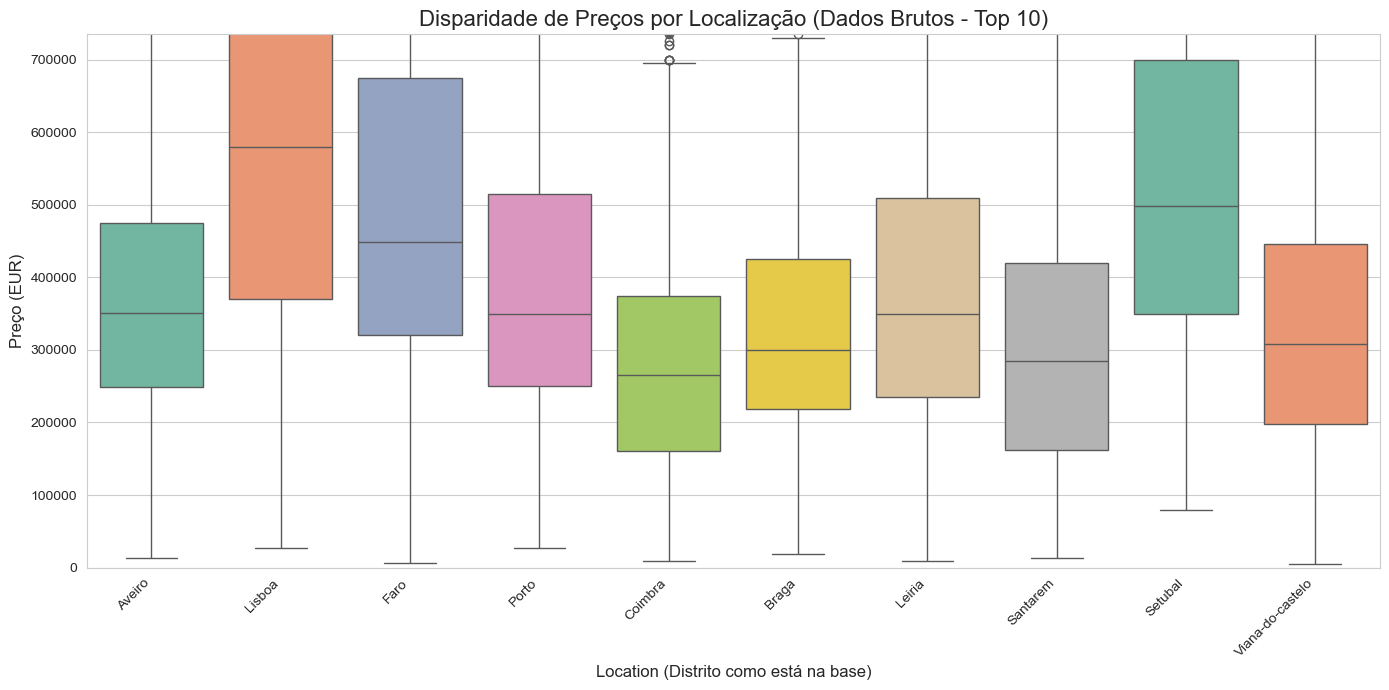

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_bruto = pd.read_csv('dataset_merged.csv')
df_bruto['Price_Num'] = df_bruto['Price'].astype(str).str.replace('€', '').str.replace(' ', '').str.replace('\xa0', '').str.replace(',', '.')
df_bruto['Price_Num'] = pd.to_numeric(df_bruto['Price_Num'], errors='coerce')
df_plot = df_bruto.dropna(subset=['Price_Num'])
top_locations = df_plot['Location'].value_counts().nlargest(10).index

plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
sns.boxplot(
    x='Location', 
    y='Price_Num', 
    data=df_plot[df_plot['Location'].isin(top_locations)],
    palette='Set2'
)
plt.title('Disparidade de Preços por Localização (Dados Brutos - Top 10)', fontsize=16)
plt.xlabel('Location (Distrito como está na base)', fontsize=12)
plt.ylabel('Preço (EUR)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_plot['Price_Num'].quantile(0.85))
plt.tight_layout()
plt.show()

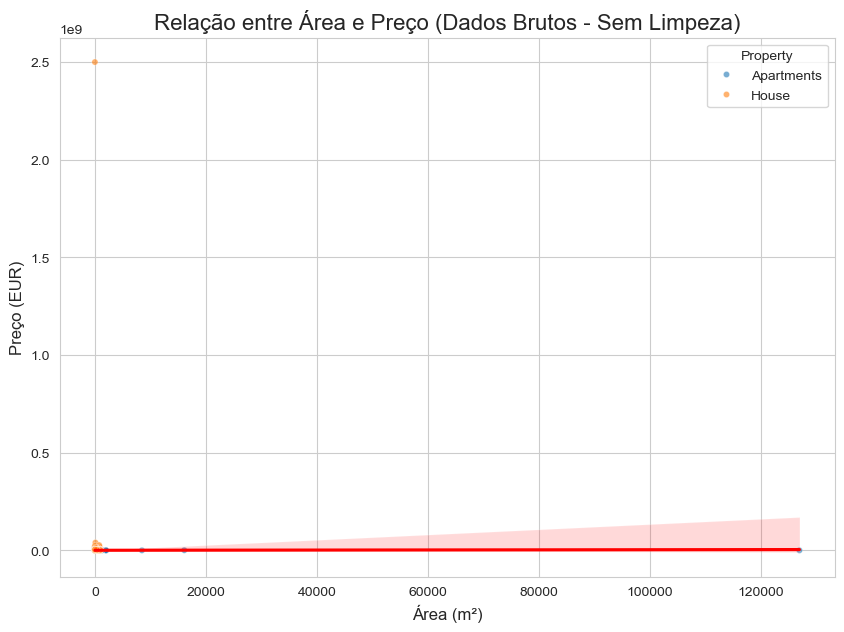

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_bruto = pd.read_csv('dataset_merged.csv')
df_bruto['Price_Num'] = df_bruto['Price'].astype(str).str.replace('€', '').str.replace(' ', '').str.replace('\xa0', '').str.replace(',', '.')
df_bruto['Price_Num'] = pd.to_numeric(df_bruto['Price_Num'], errors='coerce')
df_bruto['Area_Num'] = df_bruto['Area'].astype(str).str.replace('m2', '').str.replace(' ', '').str.replace(',', '.')
df_bruto['Area_Num'] = pd.to_numeric(df_bruto['Area_Num'], errors='coerce')
df_plot = df_bruto.dropna(subset=['Price_Num', 'Area_Num'])

plt.figure(figsize=(10, 7))
sns.set_style("whitegrid")
sns.scatterplot(x='Area_Num', y='Price_Num', data=df_plot, alpha=0.6, s=20, hue='Property')
sns.regplot(x='Area_Num', y='Price_Num', data=df_plot, scatter=False, color='red')

plt.title('Relação entre Área e Preço (Dados Brutos - Sem Limpeza)', fontsize=16)
plt.xlabel('Área (m²)', fontsize=12)
plt.ylabel('Preço (EUR)', fontsize=12)
plt.legend(title='Property')
plt.show()

## **Limpeza Final e Uniformização**

In [14]:
import pandas as pd
import numpy as np
import re
import unicodedata
def limpar_localizacao(texto):
    if pd.isna(texto): return "Desconhecido"
    texto = str(texto)
    dicionario_erros = {
        'Ã‰vora': 'Évora', 'AÃ§ores': 'Açores', 'BraganÃ§a': 'Bragança',
        'SantarÃ©m': 'Santarém', 'SetÃºbal': 'Setúbal', 'Setbal': 'Setúbal',
        'Santarm': 'Santarém', 'Vora': 'Évora', 'Set??bal': 'Setúbal',
        'Santar?©m': 'Santarém', 'Bragan?ßa': 'Bragança', '?âvora': 'Évora'
    }
    for erro, correto in dicionario_erros.items():
        if erro in texto: texto = texto.replace(erro, correto)
    texto = re.sub(r'.*:\s*', '', texto) 
    texto = texto.replace('-', ' ') 
    texto_low = texto.lower().strip()
    texto_norm = "".join(c for c in unicodedata.normalize('NFKD', texto_low) if not unicodedata.combining(c))
    ilhas = ['sao miguel', 'terceira', 'flores', 'faial', 'pico', 'sao jorge', 'santa maria', 'graciosa', 'corvo', 'acores', 'azores']
    if any(ilha in texto_norm for ilha in ilhas): return "Açores"
    distritos = {
        'evora': 'Évora', 'setubal': 'Setúbal', 'braganca': 'Bragança',
        'santarem': 'Santarém', 'castelo branco': 'Castelo Branco',
        'lisboa': 'Lisboa', 'porto': 'Porto', 'aveiro': 'Aveiro',
        'faro': 'Faro', 'beja': 'Beja', 'coimbra': 'Coimbra',
        'leiria': 'Leiria', 'guarda': 'Guarda', 'portalegre': 'Portalegre',
        'viseu': 'Viseu', 'braga': 'Braga', 'viana do castelo': 'Viana do Castelo',
        'vila real': 'Vila Real', 'madeira': 'Ilha da Madeira'
    }
    for key, value in distritos.items():
        if key in texto_norm: return value      
    return texto.title()

# 2. Função para Uniformizar Tipologia (T0 a T10)
def limpar_tipologia(valor):
    v = str(valor).lower().strip()
    if 'studio' in v: return '0'
    
    if '+' in v:
        numeros = re.findall(r'\d+', v)
        total = sum(int(n) for n in numeros if n.isdigit())
    else:
        match = re.search(r'\d+', v)
        total = int(match.group()) if match else -1
        
    if 0 <= total <= 10:
        return f'{total}'
    return None 

# 3. Função para Limpeza de Área
def limpar_area_final(row):
    v = str(row['Area']).replace('m2', '').replace(' ', '').strip()
    if 'Apartments' in str(row['Property']):
        v = v.replace(',', '.')
    else:
        if '.' in v and ',' in v: v = v.replace('.', '')
        v = v.replace(',', '.')
    try: return float(v)
    except: return None

# --- EXECUÇÃO DO FLUXO ---

# 1. Carregar o ficheiro bruto
df = pd.read_csv('dataset_merged.csv')

# 2. Aplicar Transformações
df['Location'] = df['Location'].apply(limpar_localizacao)
df['Type'] = df['Type'].apply(limpar_tipologia)

# Limpeza de Preço
df['Price'] = df['Price'].apply(lambda v: str(v).replace('€', '').replace(' ', '').replace('\xa0', '').replace(',', '.'))
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Limpeza de Área
df['Area'] = df.apply(limpar_area_final, axis=1)

# 3. FILTROS FINAIS
df = df.dropna(subset=['Price', 'Area', 'Type'])
df = df[(df['Price'] > 0) & (df['Price'] <= 1000000000)]
df = df[(df['Area'] > 10) & (df['Area'] <= 5000)]

# 4. NORMALIZAÇÃO (Colunas Log)
df['Log_Price'] = np.log1p(df['Price'])
df['Log_Area'] = np.log1p(df['Area'])

# 5. GUARDAR
df['Index'] = range(1, len(df) + 1)
df.to_csv('dataset_merged.csv', index=False, encoding='utf-8-sig')

print(f"✅ Sucesso! Ficheiro 'dataset_merged.csv' guardado com {len(df)} registos.")

✅ Sucesso! Ficheiro 'dataset_merged.csv' guardado com 33512 registos.


## **Transformação e Normalização:**

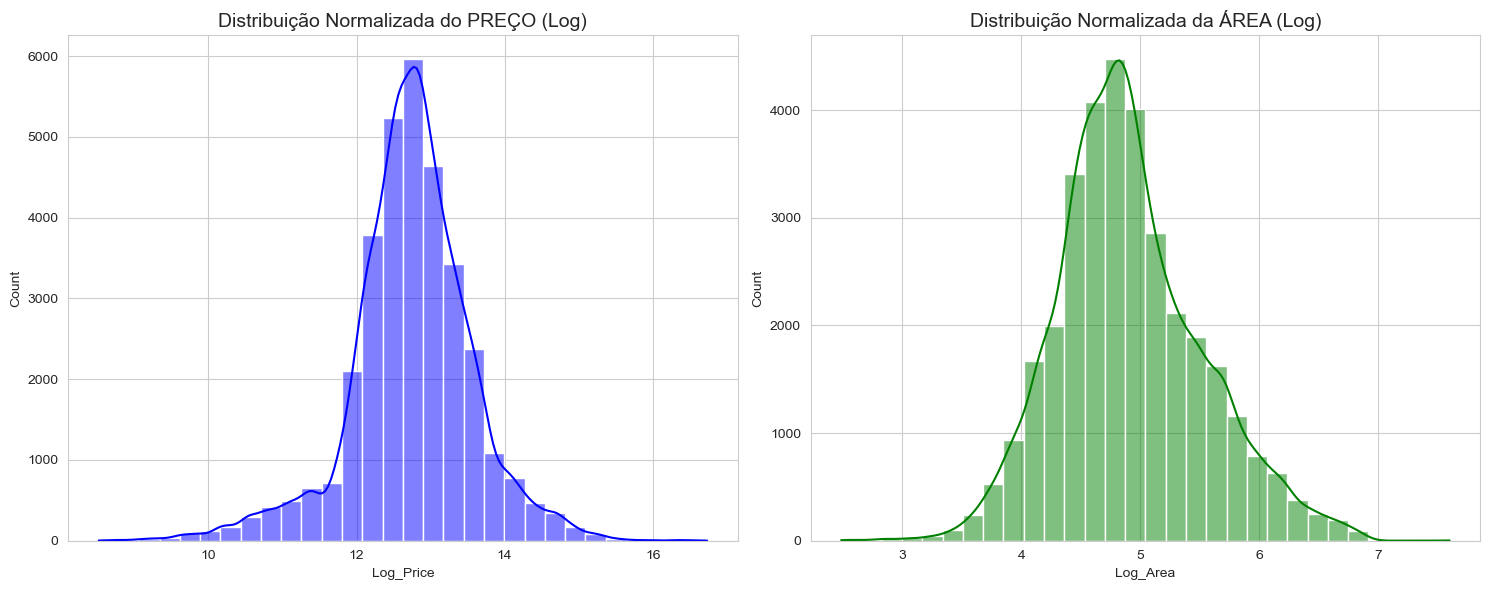

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv('dataset_merged.csv') 
df_final['Log_Price'] = np.log1p(df_final['Price'])
df_final['Log_Area'] = np.log1p(df_final['Area'])

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.histplot(df_final['Log_Price'], kde=True, color='blue', bins=30)
plt.title('Distribuição Normalizada do PREÇO (Log)', fontsize=14)
plt.subplot(1, 2, 2)
sns.histplot(df_final['Log_Area'], kde=True, color='green', bins=30)
plt.title('Distribuição Normalizada da ÁREA (Log)', fontsize=14)
plt.tight_layout()
plt.show()

escala tabulação de metros ao quadrado 

Valor no Eixo X (Log),Tradução para Preço (€),Tradução para Área (m2)

4,---,≈ 55 m2 

5,---,≈ 148 m2 

6,---,≈ 403 m2 

11,≈ 60.000 €,--- 

12,≈ 163.000 €,--- 

13,≈ 442.000 €,--- 

14,≈ 1.200.000 €,--- 

15,≈ 3.200.000 €,--- 

O que escrever lá: "Devido à assimetria identificada na EDA, aplicámos a transformação logarítmica para normalizar as variáveis Price e Area, facilitando a aprendizagem do modelo."

2. Por que é que o formato de "Sino" é importante?
O objetivo da transformação logarítmica é transformar uma distribuição assimétrica (com muitos dados amontoados num canto) numa Distribuição Normal (em forma de sino).

Como interpretar o sino:
O Centro (O Topo): Representa a média do teu mercado. Se o topo do sino do preço está no 12, a maioria dos teus imóveis custa cerca de 160.000€.
A Simetria: Significa que o logaritmo conseguiu "puxar" as casas de luxo (que estavam muito longe) e "esticar" as casas baratas, criando um equilíbrio.
A Regressão: Modelos de regressão linear funcionam muito melhor assim porque os erros tornam-se constantes (homocedasticidade), tornando as tuas previsões muito mais fiáveis.

3. Como escrever a interpretação no trabalho?Podes escrever algo deste género:"Após a aplicação da transformação logarítmica, observa-se que as variáveis Price e Area passaram a apresentar uma distribuição próxima da normalidade (formato de sino). No gráfico de Log_Price, a maior concentração de dados situa-se entre os valores 12 e 13 ($\approx$ 160k€ a 440k€), eliminando a assimetria positiva severa observada nos dados brutos. Esta normalização é fundamental para satisfazer os pressupostos do modelo de Regressão Linear Múltipla que será aplicado adiante."

## **Estatísticas Descritivas:**

In [16]:
import pandas as pd
df_final_carregado = pd.read_csv('dataset_merged.csv')
estatisticas = df_final_carregado[['Price', 'Area']].describe()
pd.options.display.float_format = '{:,.2f}'.format
print(estatisticas)

              Price      Area
count     33,512.00 33,512.00
mean     476,996.14    164.88
std      552,897.40    126.66
min        5,000.00     11.00
25%      225,000.00     89.50
50%      349,500.00    125.87
75%      545,000.00    193.00
max   18,500,000.00  2,000.00


In [17]:
import pandas as pd
df = pd.read_csv('dataset_merged.csv')

#Calcular as estatísticas básicas
stats = df[['Price', 'Area']].describe().T
stats = stats[['count', 'mean', '50%', 'std', 'min', 'max']]
stats.columns = ['Contagem', 'Média', 'Mediana', 'Desvio Padrão', 'Mínimo', 'Máximo'] #passar para Português
tabela_stats = stats.astype(object) #converter para texto

#Formatação
def formatar_euro(x):
    return f"{float(x):,.2f} €".replace(",", "X").replace(".", ",").replace("X", " ")
def formatar_area(x):
    return f"{float(x):,.2f} m²".replace(",", "X").replace(".", ",").replace("X", " ")
def formatar_int(x):
    return f"{int(x):,}".replace(",", " ")

#Aplicar as formatações
tabela_stats.loc['Price', 'Contagem'] = formatar_int(tabela_stats.loc['Price', 'Contagem'])
tabela_stats.loc['Price', 'Média'] = formatar_euro(tabela_stats.loc['Price', 'Média'])
tabela_stats.loc['Price', 'Mediana'] = formatar_euro(tabela_stats.loc['Price', 'Mediana'])
tabela_stats.loc['Price', 'Desvio Padrão'] = formatar_euro(tabela_stats.loc['Price', 'Desvio Padrão'])
tabela_stats.loc['Price', 'Mínimo'] = formatar_euro(tabela_stats.loc['Price', 'Mínimo'])
tabela_stats.loc['Price', 'Máximo'] = formatar_euro(tabela_stats.loc['Price', 'Máximo'])

#Formatar a linha da Area
tabela_stats.loc['Area', 'Contagem'] = formatar_int(tabela_stats.loc['Area', 'Contagem'])
tabela_stats.loc['Area', 'Média'] = formatar_area(tabela_stats.loc['Area', 'Média'])
tabela_stats.loc['Area', 'Mediana'] = formatar_area(tabela_stats.loc['Area', 'Mediana'])
tabela_stats.loc['Area', 'Desvio Padrão'] = formatar_area(tabela_stats.loc['Area', 'Desvio Padrão'])
tabela_stats.loc['Area', 'Mínimo'] = formatar_area(tabela_stats.loc['Area', 'Mínimo'])
tabela_stats.loc['Area', 'Máximo'] = formatar_area(tabela_stats.loc['Area', 'Máximo'])
print(tabela_stats.to_markdown(numalign="right")) 
print()

#Calcular contagens e percentagens
loc_stats = df['Location'].value_counts().reset_index()
loc_stats.columns = ['Localização', 'Nº Imóveis']
loc_stats['Percentagem'] = (loc_stats['Nº Imóveis'] / len(df)) * 100
top_loc = loc_stats.head(10).copy()
top_loc['Nº Imóveis'] = top_loc['Nº Imóveis'].apply(formatar_int)
top_loc['Percentagem'] = top_loc['Percentagem'].apply(lambda x: f"{x:.2f} %".replace(".", ","))
top_loc.index = range(1, 11)
print(top_loc.to_markdown(numalign="right", stralign="left"))

|       | Contagem   | Média        | Mediana      | Desvio Padrão   | Mínimo     | Máximo          |
|:------|:-----------|:-------------|:-------------|:----------------|:-----------|:----------------|
| Price | 33 512     | 476 996,14 € | 349 500,00 € | 552 897,40 €    | 5 000,00 € | 18 500 000,00 € |
| Area  | 33 512     | 164,88 m²    | 125,87 m²    | 126,66 m²       | 11,00 m²   | 2 000,00 m²     |

|    | Localização      | Nº Imóveis   | Percentagem   |
|---:|:-----------------|:-------------|:--------------|
|  1 | Porto            | 6 702        | 20,00 %       |
|  2 | Lisboa           | 5 230        | 15,61 %       |
|  3 | Faro             | 3 135        | 9,35 %        |
|  4 | Setúbal          | 2 813        | 8,39 %        |
|  5 | Aveiro           | 2 225        | 6,64 %        |
|  6 | Braga            | 2 060        | 6,15 %        |
|  7 | Leiria           | 1 730        | 5,16 %        |
|  8 | Viana do Castelo | 1 630        | 4,86 %        |
|  9 | Coimbra       

## **Análise Exploratória de Dados (EDA)**

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_final = pd.read_csv('dataset_merged.csv')
sns.set_style("whitegrid") 
plt.rcParams['figure.figsize'] = (15, 6) 
limite_price = df_final['Price'].quantile(0.99)
limite_area = df_final['Area'].quantile(0.99)
df_eda = df_final[
    (df_final['Price'] <= limite_price) & 
    (df_final['Area'] <= limite_area)
].copy()

print(f"DataFrame EDA criado com {len(df_eda)} linhas para visualização.")

DataFrame EDA criado com 32899 linhas para visualização.


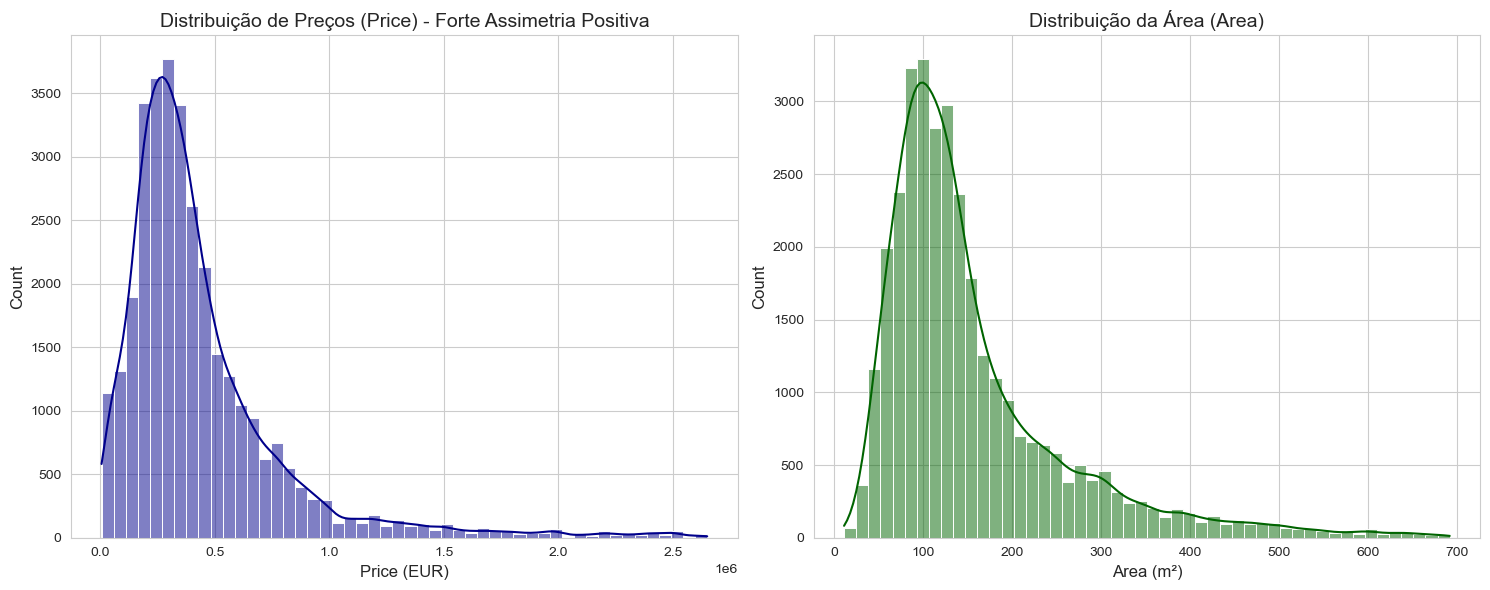

In [19]:
#Gráfico 1: Assimetria de Price e Area
plt.figure(figsize=(15, 6))

#Histograma da variável alvo (Price)
plt.subplot(1, 2, 1) # 1 linha, 2 colunas, posição 1
sns.histplot(df_eda['Price'], kde=True, bins=50, color='darkblue')
plt.title('Distribuição de Preços (Price) - Forte Assimetria Positiva', fontsize=14)
plt.xlabel('Price (EUR)', fontsize=12)
plt.ylabel('Count', fontsize=12)

#Histograma da variável explicativa (Area)
plt.subplot(1, 2, 2) # 1 linha, 2 colunas, posição 2
sns.histplot(df_eda['Area'], kde=True, bins=50, color='darkgreen')
plt.title('Distribuição da Área (Area)', fontsize=14)
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.tight_layout()
plt.show()

Faz sentido deixar estes graficos assimetricos aqui, sendo que ja fiz a distribuição logaritmica antes??

A AED serve para compreender os dados como eles são na realidade. No mercado imobiliário, os dados são naturalmente assimétricos: existem milhares de apartamentos T1/T2 "baratos" e poucas mansões de luxo.

Se os gráficos fossem simétricos logo na AED, significava que os dados já estavam transformados ou que não eram reais.

No seu relatório, use estes gráficos para escrever: "Observa-se uma forte assimetria positiva, o que é característico do mercado residencial, justificando a necessidade de uma transformação logarítmica na fase seguinte."

2. A Sequência Lógica do Trabalho (CRISP-DM)
Para a entrega da 1.ª Etapa, a estrutura deve ser esta:

AED (Dados Sujos): Mostra os gráficos "vazios" por causa dos biliões.

Limpeza: Aplica o código que fizemos para limpar localizações e preços.

AED (Dados Limpos - O que tem agora): Mostra os gráficos que me enviou (com barras visíveis, mas assimétricos).

Preparação (Transformação): Aplica o Logaritmo para tornar os dados simétricos.

O que escrever lá: "Observa-se uma forte assimetria positiva. Isto indica que o mercado está concentrado em valores baixos/médios, com alguns imóveis de luxo a puxar a média para cima."

C:\Users\Sara Simões\AppData\Local\Temp\ipykernel_19940\1977873049.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


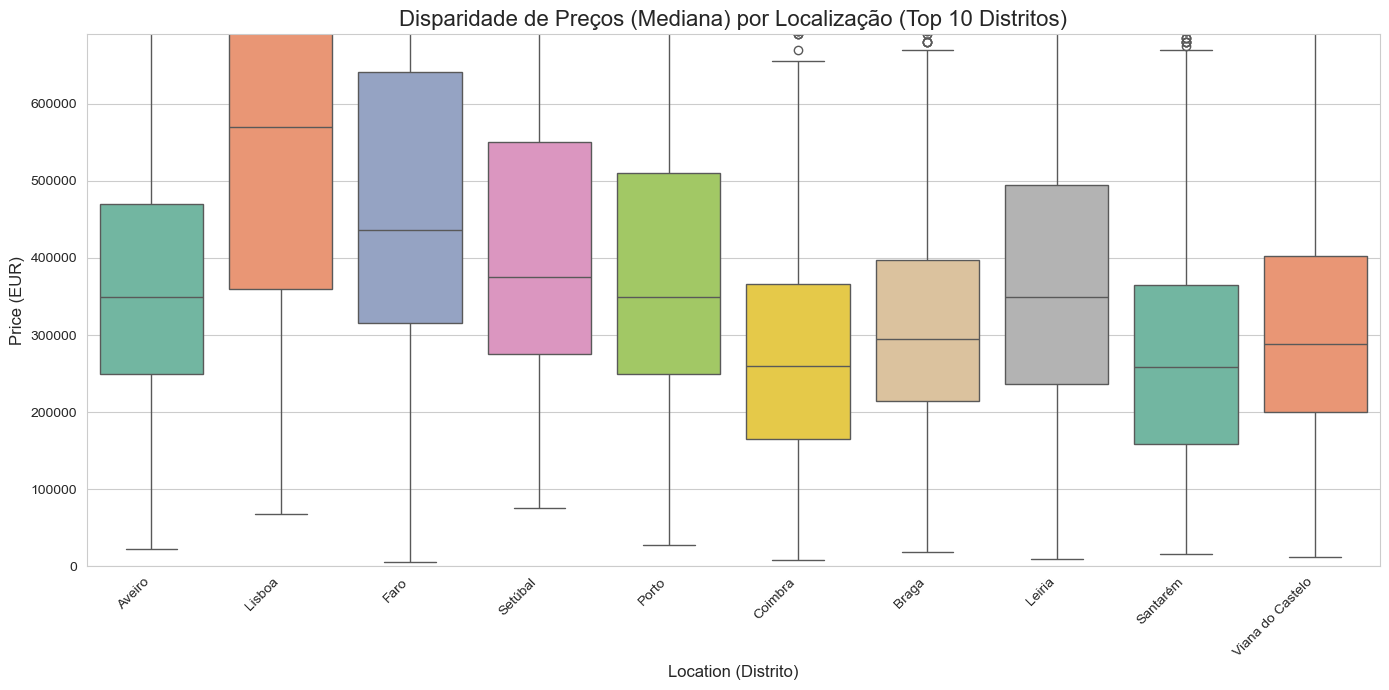

In [20]:
#Gráfico 2: Influência da Localização
top_locations = df_eda['Location'].value_counts().nlargest(10).index
plt.figure(figsize=(14, 7))
sns.boxplot(
    x='Location', 
    y='Price', 
    data=df_eda[df_eda['Location'].isin(top_locations)],
    palette='Set2'
)
plt.title('Disparidade de Preços (Mediana) por Localização (Top 10 Distritos)', fontsize=16)
plt.xlabel('Location (Distrito)', fontsize=12)
plt.ylabel('Price (EUR)', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rodar os nomes para melhor leitura
plt.ylim(0, df_eda['Price'].quantile(0.85)) # Limitar y-axis para focar na distribuição central
plt.tight_layout()
plt.show()

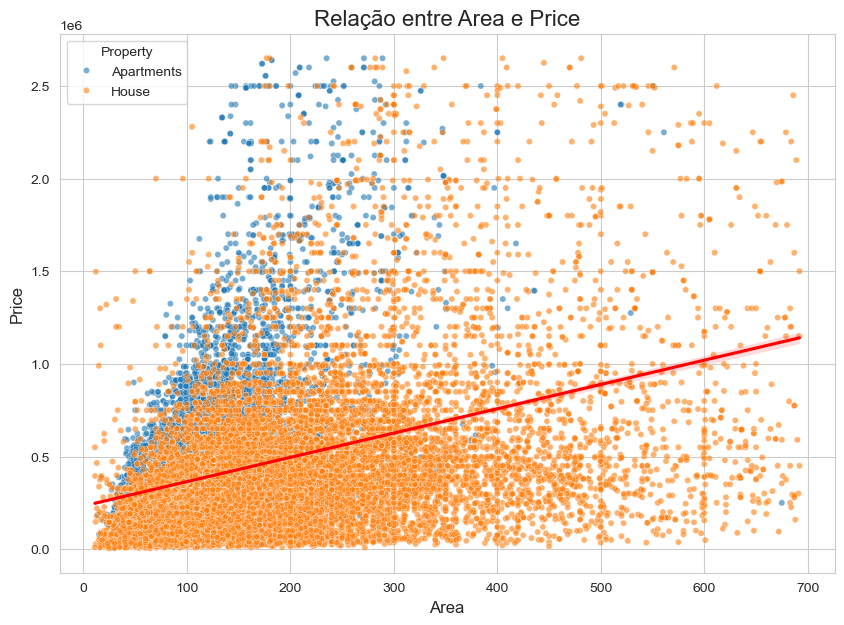

In [21]:
#Gráfico 3: Relação entre Area e Price
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Area', y='Price', data=df_eda, alpha=0.6, s=20, hue= 'Property')
plt.title('Relação entre Area e Price', fontsize=16)
plt.xlabel('Area (m²)', fontsize=12)
plt.ylabel('Price (EUR)', fontsize=12)
sns.regplot(x='Area', y='Price', data=df_eda, scatter=False, color='red')
plt.legend(title='Property')
plt.show()

## **Qualidade dos Dados**

In [22]:
import pandas as pd
df = pd.read_csv('dataset_merged.csv')
total_registos = len(df)

#Inconsistências críticas 
price_zero = len(df[df['Price'] == 0]) #Contar quantas linhas têm price = 0
pct_price_zero = (price_zero / total_registos) * 100
area_zero = len(df[df['Area'] == 0]) #Contar quantas linhas têm area = 0
pct_area_zero = (area_zero / total_registos) * 100
print(f"Registos com Price = 0: {price_zero} ({pct_price_zero:.2f}%)")
print(f"Registos com Area  = 0: {area_zero} ({pct_area_zero:.2f}%)")

#Verificação de segurança
if price_zero > 0 or area_zero > 0:
    print("ALERTA: Estes registos devem ser removidos antes da modelação.")
else:
    print("OK: Não existem registos com valor zero nestas variáveis.")
print()

#Valores Omissos (Missing Values) 
missing_count = df.isnull().sum() #Calcular contagem e percentagem de nulos por coluna
missing_pct = (df.isnull().sum() / total_registos) * 100
tabela_missing = pd.DataFrame({
    'Valores Omissos': missing_count,
    'Percentagem': missing_pct
})
tabela_missing['Percentagem'] = tabela_missing['Percentagem'].map('{:.2f} %'.format)
if tabela_missing.empty and missing_count.sum() == 0:
    print("   ✅  Perfeito! Não existem valores omissos (NaN) no dataset.")
else:
    print(tabela_missing.to_markdown(numalign="right", stralign="left"))

Registos com Price = 0: 0 (0.00%)
Registos com Area  = 0: 0 (0.00%)
OK: Não existem registos com valor zero nestas variáveis.

|           |   Valores Omissos | Percentagem   |
|:----------|------------------:|:--------------|
| Index     |                 0 | 0.00 %        |
| Type      |                 0 | 0.00 %        |
| Price     |                 0 | 0.00 %        |
| Area      |                 0 | 0.00 %        |
| Location  |                 0 | 0.00 %        |
| Property  |                 0 | 0.00 %        |
| Log_Price |                 0 | 0.00 %        |
| Log_Area  |                 0 | 0.00 %        |


# **Parte 2**

## 4. **Modelação**

### 4.3.1. **Regressão Linear Global**

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error

df_model = df[(df['Price'] > 0) & (df['Area'] > 0)].dropna(subset=['Price', 'Area', 'Location', 'Property']).copy()
limite_preco = df_model['Price'].quantile(0.95)
df_model = df_model[df_model['Price'] < limite_preco]
df_model['Type'] = pd.to_numeric(df_model['Type'], errors='coerce')
df_model = df_model.dropna(subset=['Type']) 
df_final = pd.get_dummies(df_model, columns=['Location', 'Property'], drop_first=True)
X = df_final.select_dtypes(include=[np.number]).drop(['Price', 'Index'], axis=1, errors='ignore')
y = df_final['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Treino: {X_train.shape[0]} imóveis")
print(f"Teste: {X_test.shape[0]} imóveis")
print()

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² (Coeficiente de Determinação): {r2:.4f}")
print(f"Erro Médio Absoluto (MAE): {mae:.2f} €")
print(f"RMSE do Modelo Linear Global: {rmse_linear:.2f} €")

print(f"DataFrame EDA criado com {len(df_final)} linhas para visualização.")

Treino: 25464 imóveis
Teste: 6366 imóveis

R² (Coeficiente de Determinação): 0.7892
Erro Médio Absoluto (MAE): 77903.98 €
RMSE do Modelo Linear Global: 109455.19 €
DataFrame EDA criado com 31830 linhas para visualização.


0,5312 - o modelo linear consegue explicar mais de metade da variação dos preços dos imoveis, usando apenas a area, a tipologia e a localização



### 4.3.2. **Regressão Linear Individual por Distrito**

In [30]:
resultados_distritos = []

distritos = df_model['Location'].unique()

for distrito in distritos:
    df_d = df_model[df_model['Location'] == distrito]
    
    if len(df_d) > 50:
        X_d = df_d[['Area', 'Type']]
        y_d = df_d['Price']
        
        X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)
        
        model_d = LinearRegression().fit(X_train_d, y_train_d)
        r2_d = model_d.score(X_test_d, y_test_d)
        mae_d = mean_absolute_error(y_test_d, model_d.predict(X_test_d))
        
        resultados_distritos.append({'Distrito': distrito, 'R2': r2_d, 'MAE': mae_d, 'Amostra': len(df_d)})

df_resultados = pd.DataFrame(resultados_distritos).sort_values(by='R2', ascending=False)
print(df_resultados)

            Distrito   R2        MAE  Amostra
3            Setúbal 0.53 102,295.89     2678
6              Braga 0.52  86,437.06     2009
15          Bragança 0.46  72,920.46      243
10          Santarém 0.43 106,330.18     1447
11    Castelo Branco 0.43  91,585.85      890
4              Porto 0.34 125,226.94     6524
18             Évora 0.32 163,318.92      567
2               Faro 0.31 147,085.47     2845
13  Viana do Castelo 0.28 110,126.11     1609
8    Ilha da Madeira 0.26 140,267.60      327
16        Portalegre 0.26 130,908.17      602
14             Viseu 0.22 135,030.46      583
0             Aveiro 0.22 125,204.69     2201
7             Leiria 0.21 165,963.40     1674
1             Lisboa 0.21 194,852.05     4435
5            Coimbra 0.20 118,765.75     1619
17            Guarda 0.19  97,699.19      387
12              Beja 0.18 180,637.15      642
9          Vila Real 0.15 139,446.33      514


nao fez açores porque pusemos no código que tem de ter amostras superiores a 50... se faltar algum é por causa disso tambem

4.4.1. **Árvore de Decisão incial**

O R² do teu modelo Global é: 0.313
(Isto diz-te o quão bom o modelo é. 1.0 é perfeito, 0.0 é péssimo)
Imagem 'arvore_decisao_imagem.png' guardada com sucesso!


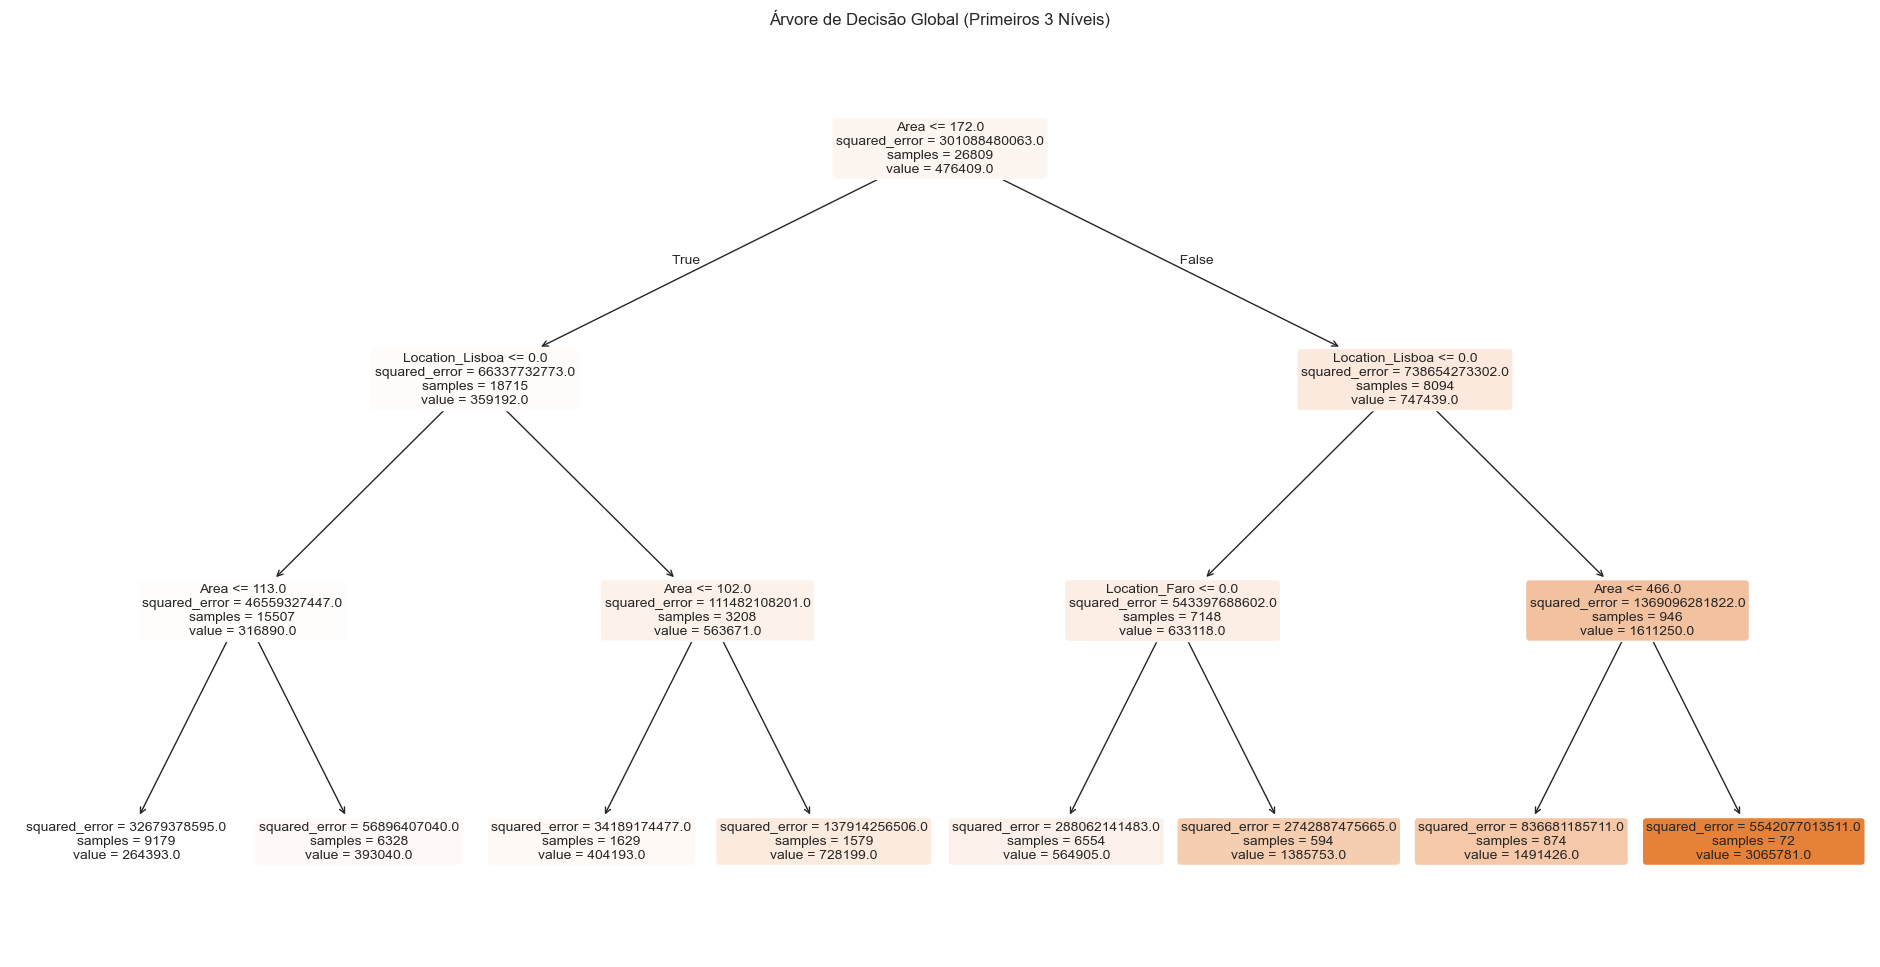

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

df = pd.read_csv('dataset_merged.csv') 
X = pd.get_dummies(df[['Area', 'Type', 'Location', 'Property']], drop_first=True)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
modelo_arvore = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_arvore.fit(X_train, y_train)
r2 = modelo_arvore.score(X_test, y_test)
print(f"O R² do teu modelo Global é: {r2:.3f}")
print("(Isto diz-te o quão bom o modelo é. 1.0 é perfeito, 0.0 é péssimo)")
plt.figure(figsize=(24, 12)) 
plot_tree(modelo_arvore, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          precision=0, 
          fontsize=10)
plt.title("Árvore de Decisão Global (Primeiros 3 Níveis)")
plt.savefig('arvore_decisao_imagem.png', dpi=300, bbox_inches='tight')
print("Imagem 'arvore_decisao_imagem.png' guardada com sucesso!")

Arvore ideal

A procurar a profundidade ideal... (Isto pode demorar alguns segundos)

--- RESULTADOS DA OTIMIZAÇÃO ---
A Profundidade Ideal encontrada foi: 7
O R² deste modelo nos dados de teste é: 0.442


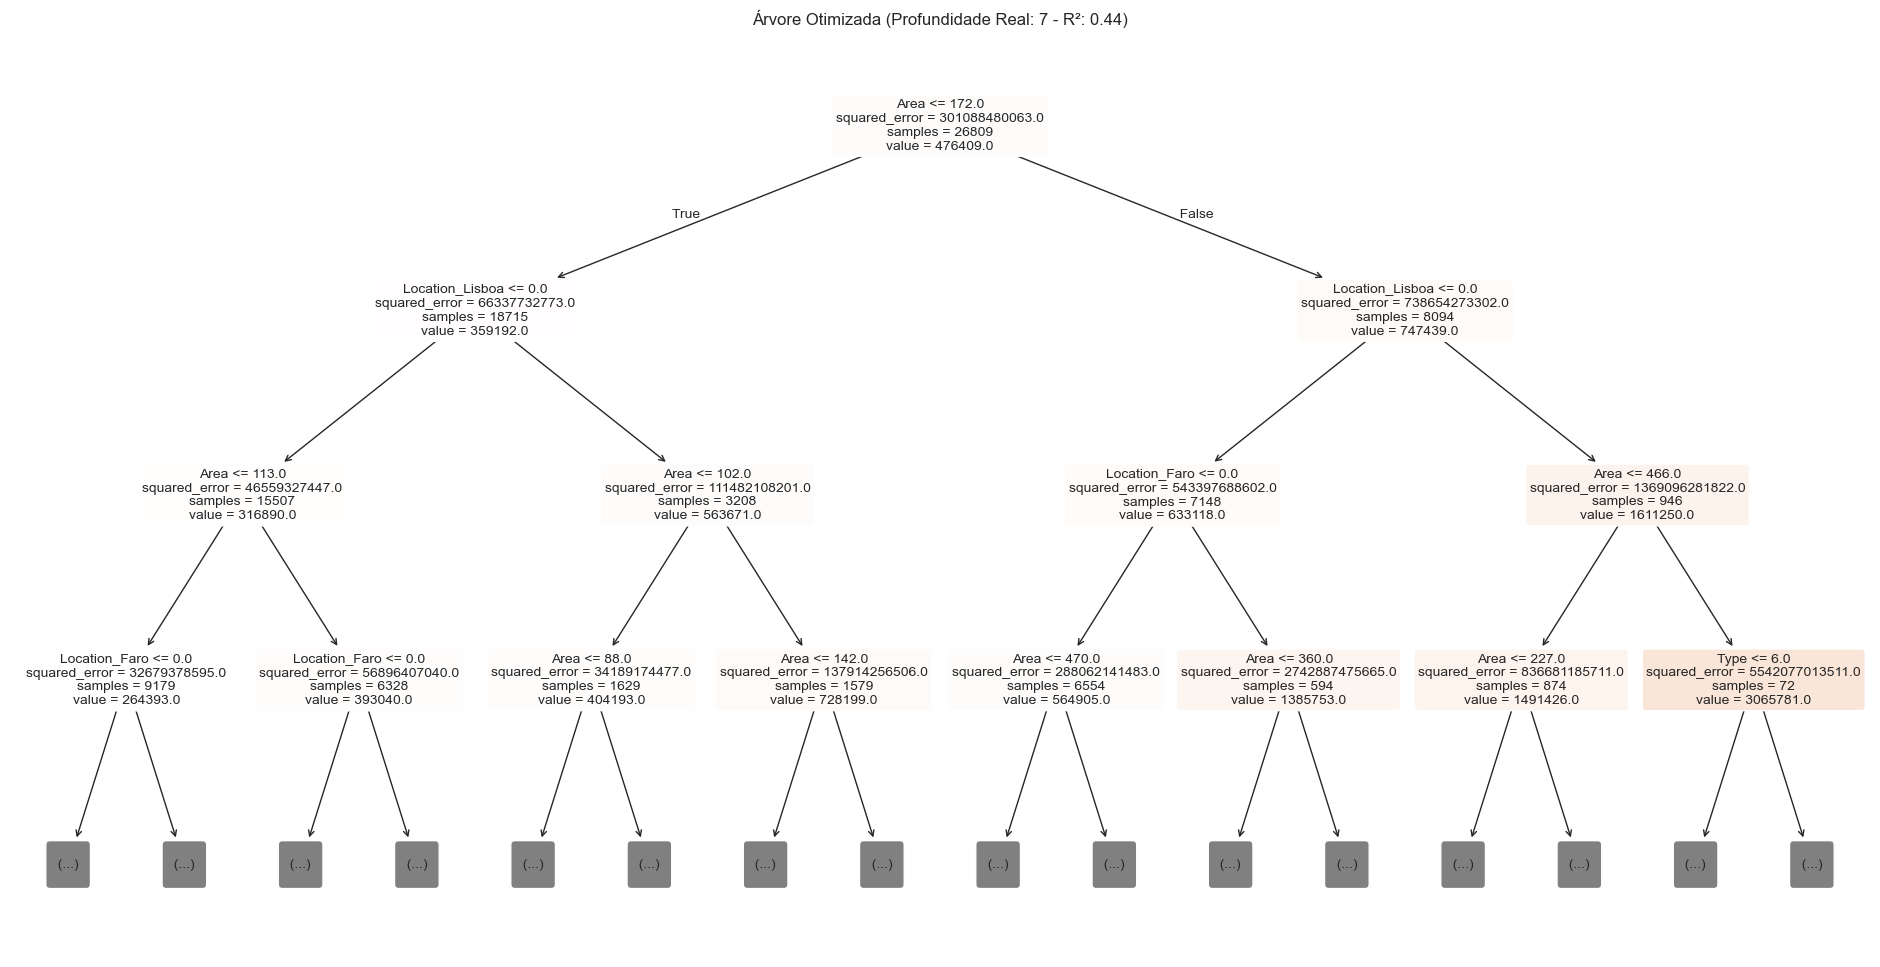

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV

df = pd.read_csv('dataset_merged.csv') 
X = pd.get_dummies(df[['Area', 'Type', 'Location', 'Property']], drop_first=True)
y = df['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
parametros_para_testar = {'max_depth': [3, 5, 7, 10, 12, 15, 20]}
print("A procurar a profundidade ideal... (Isto pode demorar alguns segundos)")
grid = GridSearchCV(DecisionTreeRegressor(random_state=42), parametros_para_testar, cv=5)
grid.fit(X_train, y_train)
melhor_profundidade = grid.best_params_['max_depth']
melhor_modelo = grid.best_estimator_
print(f"\n--- RESULTADOS DA OTIMIZAÇÃO ---")
print(f"A Profundidade Ideal encontrada foi: {melhor_profundidade}")
print(f"O R² deste modelo nos dados de teste é: {melhor_modelo.score(X_test, y_test):.3f}")
plt.figure(figsize=(24, 12))
plot_tree(melhor_modelo, 
          feature_names=X.columns, 
          filled=True, 
          rounded=True, 
          precision=0, 
          fontsize=10,
          max_depth=3)
plt.title(f"Árvore Otimizada (Profundidade Real: {melhor_profundidade} - R²: {melhor_modelo.score(X_test, y_test):.2f})")
plt.savefig('arvore_decisao_otimizada.png', dpi=300, bbox_inches='tight')

Calcular MAE e RMSE

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. O modelo adivinha os preços
y_pred = melhor_modelo.predict(X_test)

# 2. Calcular MAE 
mae = mean_absolute_error(y_test, y_pred)

# 3. Calcular RMSE 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- RELATÓRIO FINAL DE ERROS ---")
print(f"R² (Qualidade Explicação): {melhor_modelo.score(X_test, y_test):.3f}")
print(f"MAE (Erro Médio Absoluto): {mae:.2f} €  <-- Compara este com o Elemento 1")
print(f"RMSE (Raiz do Erro Quadrático): {rmse:.2f} € <-- Mostra robustez científica")


--- RELATÓRIO FINAL DE ERROS ---
R² (Qualidade Explicação): 0.442
MAE (Erro Médio Absoluto): 197739.50 €  <-- Compara este com o Elemento 1
RMSE (Raiz do Erro Quadrático): 425299.32 € <-- Mostra robustez científica


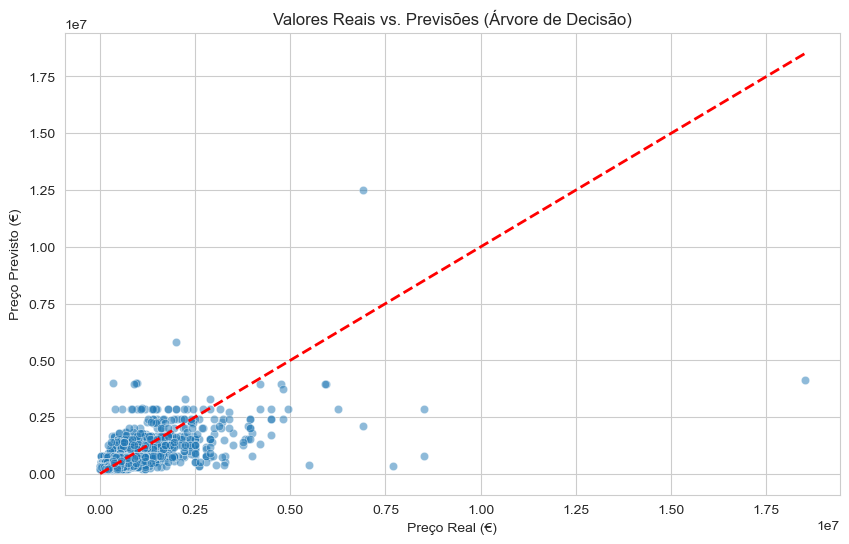

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Gerar o Gráfico de Dispersão
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)

# 2. Adicionar a linha de tendência (perfeição)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')

# 3. Configurações estéticas
plt.title('Valores Reais vs. Previsões (Árvore de Decisão)')
plt.xlabel('Preço Real (€)')
plt.ylabel('Preço Previsto (€)')
plt.grid(True)
plt.show()

# 4. EXTRA: Exportar os dados para tu fazeres no teu Excel
df_resultados = pd.DataFrame({'Real': y_test, 'Previsto': y_pred})
df_resultados.to_csv('resultados_modelo.csv', index=False)

In [35]:
Importância das variaveis

SyntaxError: invalid syntax (3555777618.py, line 1)

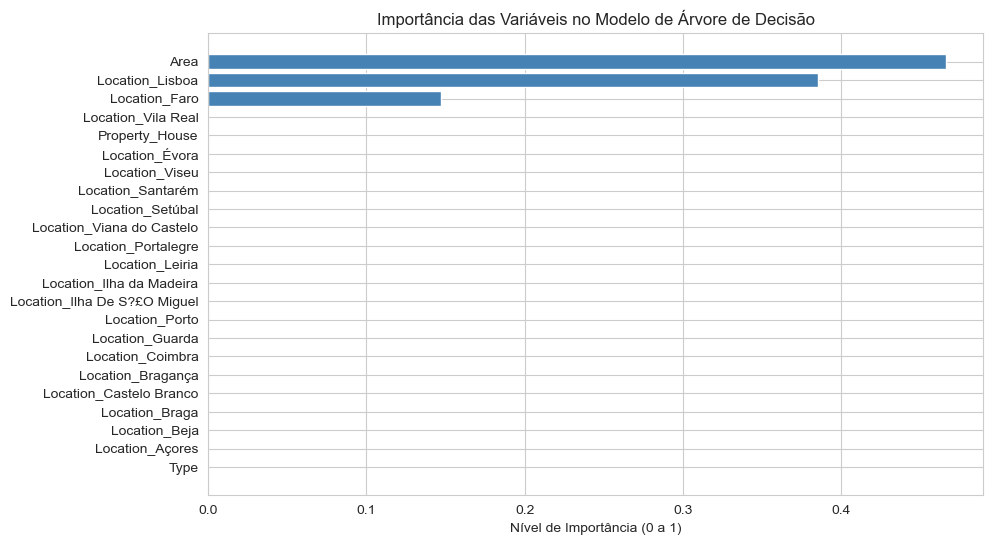

                        Variável  Importância
0                           Area         0.47
13               Location_Lisboa         0.39
8                  Location_Faro         0.15
4                 Location_Braga         0.00
1                           Type         0.00
2                Location_Açores         0.00
3                  Location_Beja         0.00
7               Location_Coimbra         0.00
5              Location_Bragança         0.00
6        Location_Castelo Branco         0.00
9                Location_Guarda         0.00
12               Location_Leiria         0.00
15                Location_Porto         0.00
10  Location_Ilha De S?£O Miguel         0.00
11      Location_Ilha da Madeira         0.00
17              Location_Setúbal         0.00
18     Location_Viana do Castelo         0.00
14           Location_Portalegre         0.00
16             Location_Santarém         0.00
22                Property_House         0.00
21                Location_Évora  

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extrair as importâncias
importancias = modelo_arvore.feature_importances_
nomes_variaveis = X.columns

# 2. Criar um DataFrame para facilitar a visualização
df_importancia = pd.DataFrame({'Variável': nomes_variaveis, 'Importância': importancias})
df_importancia = df_importancia.sort_values(by='Importância', ascending=True)

# 3. Gerar o gráfico automático (Gráfico W)
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variável'], df_importancia['Importância'], color='steelblue')
plt.xlabel('Nível de Importância (0 a 1)')
plt.title('Importância das Variáveis no Modelo de Árvore de Decisão')
plt.show()

# 4. Mostrar os valores exatos para a tua Tabela
print(df_importancia.sort_values(by='Importância', ascending=False))